In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [3]:
from google.colab import files

uploaded = files.upload()


Saving taxi-fares.csv to taxi-fares (1).csv


In [14]:
df = pd.read_csv('taxi-fares.csv')

In [15]:
print("Dataset Shape:", df.shape)

Dataset Shape: (55368, 8)


In [16]:
print(df.head())

                             key  fare_amount          pickup_datetime  \
0  2014-06-15 17:11:00.000000107          7.0  2014-06-15 17:11:00 UTC   
1   2011-03-14 22:43:00.00000095          4.9  2011-03-14 22:43:00 UTC   
2   2011-02-14 15:14:00.00000067          6.1  2011-02-14 15:14:00 UTC   
3   2009-10-29 11:29:00.00000040          6.9  2009-10-29 11:29:00 UTC   
4   2011-07-02 10:38:00.00000028         10.5  2011-07-02 10:38:00 UTC   

   pickup_longitude  pickup_latitude  dropoff_longitude  dropoff_latitude  \
0        -73.995420        40.759662         -73.987607         40.751247   
1        -73.993552        40.731110         -73.998497         40.737200   
2        -73.972380        40.749527         -73.990638         40.745328   
3        -73.973703        40.763542         -73.984253         40.758603   
4        -73.921262        40.743615         -73.967383         40.765162   

   passenger_count  
0                1  
1                5  
2                1  
3       

In [17]:
df = df.dropna()

In [18]:
X = df[['pickup_longitude',
        'pickup_latitude',
        'dropoff_longitude',
        'dropoff_latitude',
        'passenger_count']]

y = df['fare_amount']

In [19]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42
)

In [20]:
rf = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf.fit(X_train, y_train)


RandomForestRegressor(random_state=42)

In [21]:
y_pred = rf.predict(X_test)

In [22]:
print("\nModel Performance")
print("MAE :", mean_absolute_error(y_test, y_pred))
print("MSE :", mean_squared_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))


Model Performance
MAE : 2.287258182317813
MSE : 19.226213357548396
RMSE: 4.384770616297778
R2 Score: 0.7899709687048262


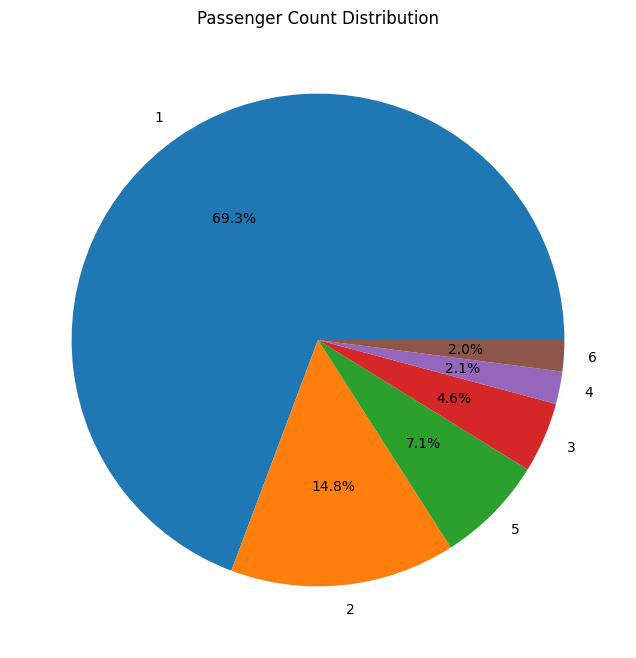

In [23]:
plt.figure(figsize=(8,8))

df['passenger_count'].value_counts().head(6).plot(
    kind='pie',
    autopct='%1.1f%%'
)

plt.title('Passenger Count Distribution')
plt.ylabel('')
plt.show()

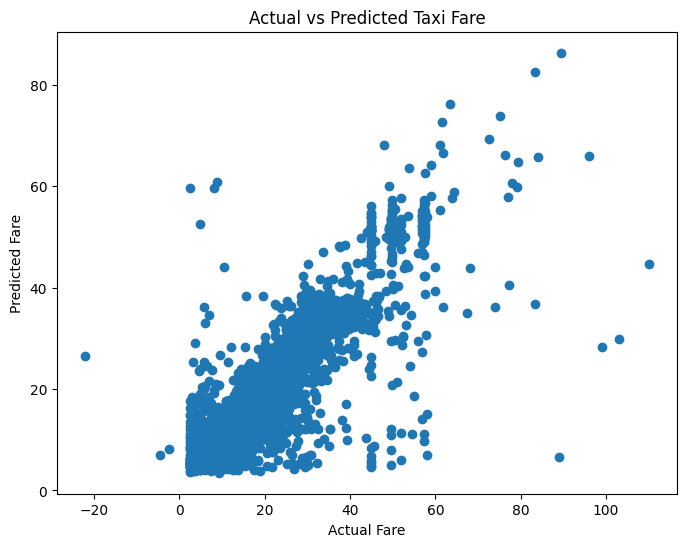

In [24]:
plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Fare")
plt.ylabel("Predicted Fare")
plt.title("Actual vs Predicted Taxi Fare")
plt.show()

In [25]:
new_trip = pd.DataFrame({
    'pickup_longitude': [-73.98],
    'pickup_latitude': [40.75],
    'dropoff_longitude': [-73.95],
    'dropoff_latitude': [40.78],
    'passenger_count': [2]
})

predicted_fare = rf.predict(new_trip)

print("Predicted Fare = $", round(predicted_fare[0], 2))

Predicted Fare = $ 11.86
